RFM → Pareto/NBD → Gamma‑Gamma → CLV → K‑Means segmentation flow

Builds a transaction table at order level (one row per customer_id + transaction_id)

Creates RFM summary compatible with lifetimes

Fits Pareto/NBD (purchase frequency) and Gamma‑Gamma (monetary value)

Computes predicted CLV (e.g., next 180 days)

Evaluates with calibration/holdout

Segments customers with K‑Means and visualizes

1. Imports & plotting setup

Libraries: pandas/numpy (data), matplotlib/seaborn (plots), lifetimes (buy-’til-you-die models), sklearn (K-Means, scaling, PCA).

In [28]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
from lifetimes import ParetoNBDFitter, GammaGammaFitter
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions,
    plot_calibration_purchases_vs_holdout_purchases,
    plot_history_alive
)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [29]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
from lifetimes import ParetoNBDFitter, GammaGammaFitter
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions,
    plot_calibration_purchases_vs_holdout_purchases,
    plot_history_alive
)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [30]:

from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string
# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values() 

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)

# 2. Load data

my_schema = "team_3"

mart_all_data = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_all_data;",
    engine,
    parse_dates=['transaction_date']
)


2) Build a clean transaction table

- Ensures transaction_date is datetime
- Removes rows with non-positive revenue/quantity (refunds, bad rows)
- Aggregates to one row per (customer_id, transaction_id) with:

transaction_date = min(date in that order)
monetary_value = sum(revenue in that order)

- Caps extreme order values at the 99.9th percentile (winsorization).

NB: The lifetimes package expects a tidy table: customer_id, datetime, monetary_value with positive values and one row per purchase. Caps reduce the impact of crazy outliers on the model.

In [31]:
# Ensure proper dtypes
mart_all_data['transaction_date'] = pd.to_datetime(mart_all_data['transaction_date'], errors='coerce')

# Filter out refunds/zero or negative revenue if present
df = mart_all_data.copy()
df = df[df['revenue'] > 0]
df = df[df['quantity'] > 0]

# Build an order-level monetary value (one row per order)
# If a transaction spans multiple rows, sum revenue to get order value
orders = (
    df.groupby(['customer_id', 'transaction_id'], as_index=False)
      .agg(transaction_date=('transaction_date', 'min'),
           monetary_value=('revenue', 'sum'))
)

# Optional: cap extreme order values to reduce noise (winsorize)
q_hi = orders['monetary_value'].quantile(0.999)
orders['monetary_value'] = np.where(orders['monetary_value'] > q_hi, q_hi, orders['monetary_value'])

orders.head()


,customer_id,transaction_id,transaction_date,monetary_value
0,12346,38223,2019-09-15,180.9900
1,12347,23979,2019-03-24,41.8000
2,12347,23980,2019-03-24,557.0000
3,12347,23981,2019-03-24,353.5200
4,12347,23984,2019-03-24,4668.0513


3. RFM summary for lifetimes

What it does: summary_data_from_transaction_data(..., freq='D') returns per-customer:

frequency = number of repeat purchases (first purchase doesn’t count),

recency = days from first purchase to last purchase,

T = days from first purchase to end of observation window,

monetary_value = average order value for that customer.

Why: These are the sufficient statistics for probabilistic CLV models.

In [32]:
# lifetimes expects a transaction table: customer_id, datetime, monetary_value
# We'll use daily frequency ('D'). observation_period_end defaults to max date.
rfm_summary = summary_data_from_transaction_data(
    transactions=orders,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='monetary_value',
    freq='D'   # daily granularity
)

rfm_summary = rfm_summary.reset_index()  # customer_id becomes a column
rfm_summary.head()

,customer_id,frequency,recency,T,monetary_value
0,12346,0.0,0.0,107.0,0.00
1,12347,2.0,223.0,282.0,1425.26
2,12348,1.0,119.0,192.0,760.24
3,12350,0.0,0.0,17.0,0.00
4,12356,0.0,0.0,107.0,0.00


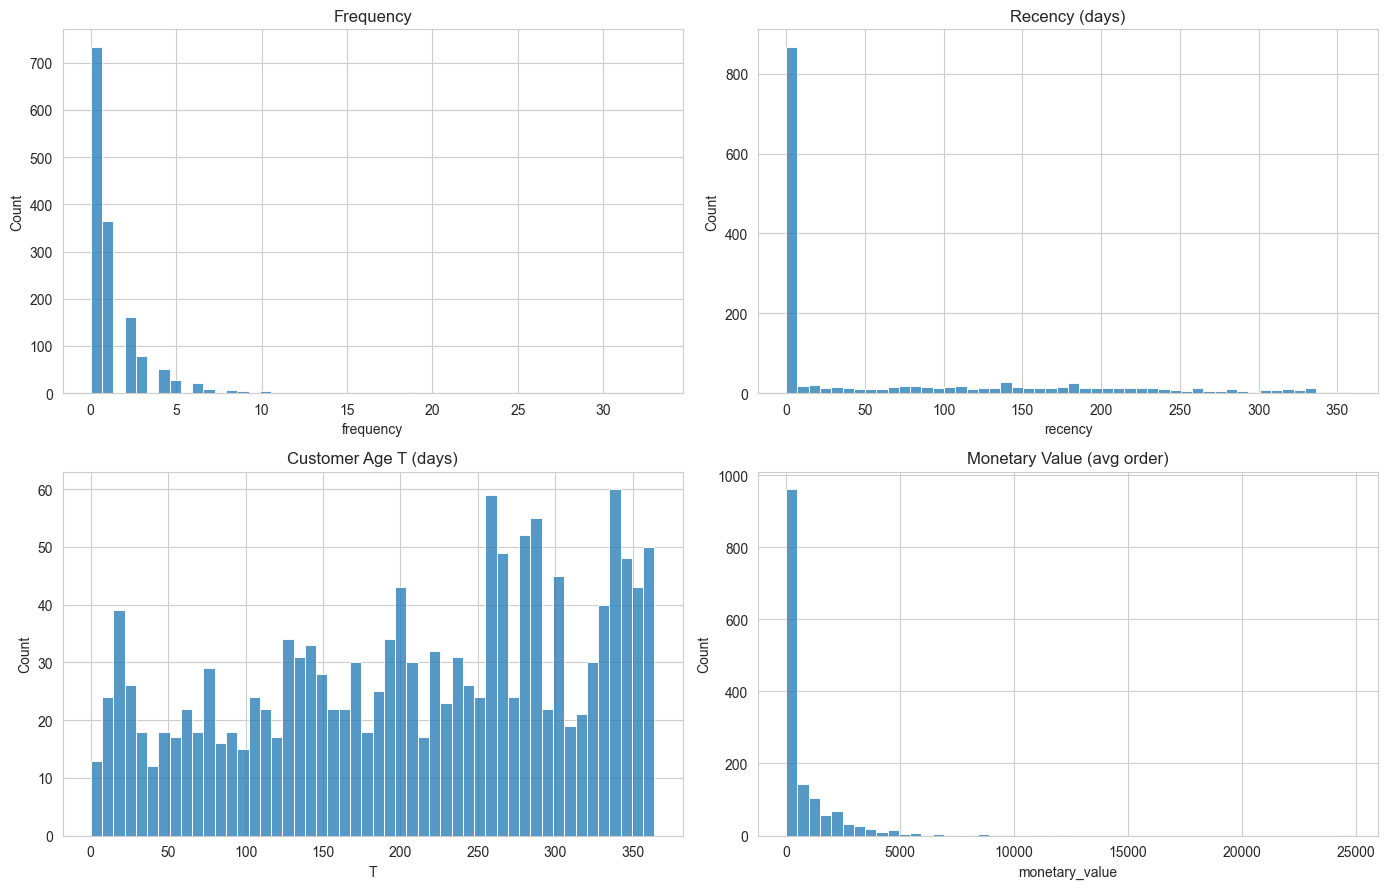

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(rfm_summary['frequency'], bins=50, ax=axes[0,0]); axes[0,0].set_title('Frequency')
sns.histplot(rfm_summary['recency'], bins=50, ax=axes[0,1]); axes[0,1].set_title('Recency (days)')
sns.histplot(rfm_summary['T'], bins=50, ax=axes[1,0]); axes[1,0].set_title('Customer Age T (days)')
sns.histplot(rfm_summary['monetary_value'], bins=50, ax=axes[1,1]); axes[1,1].set_title('Monetary Value (avg order)')
plt.tight_layout(); plt.show()

4. Fit Pareto/NBD (purchase frequency process)

Pareto/Negative-Binomial Distribution model estimates a customer's activeness. We can answer questions such as: What is the probability of this many purchases being made by a specific customer, and how will it change over time?

ParetoNBDFitter(penalizer_coef=0.1).fit(frequency, recency, T)

Why: Learns the probability distribution of how often each customer will buy in the future. The penalizer stabilizes the fit on messy data.

Diagnostics plotted:

Frequency/Recency matrix and Probability-alive matrix → sanity checks that model behavior looks reasonable.

Period transactions plot → compares model-implied vs observed counts by period.

In [34]:
# Choose a mild penalizer to stabilize estimates
pareto = ParetoNBDFitter(penalizer_coef=0.1)
pareto.fit(rfm_summary['frequency'], rfm_summary['recency'], rfm_summary['T'])

print(pareto)

<lifetimes.ParetoNBDFitter: fitted with 1468 subjects, alpha: 219.64, beta: 3.40, r: 2.03, s: 0.16>


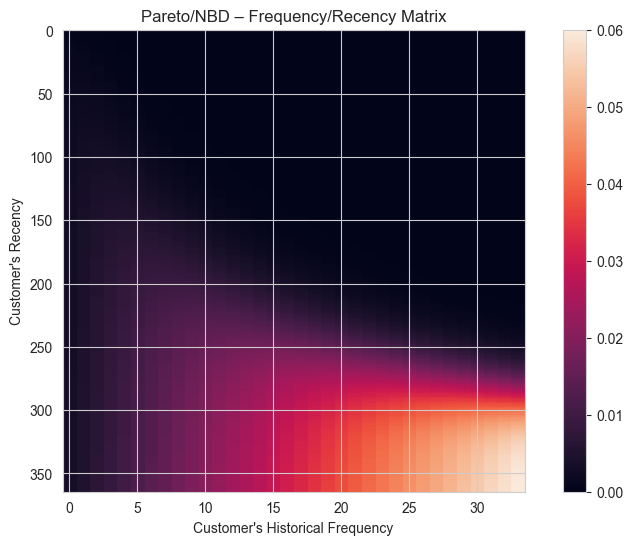

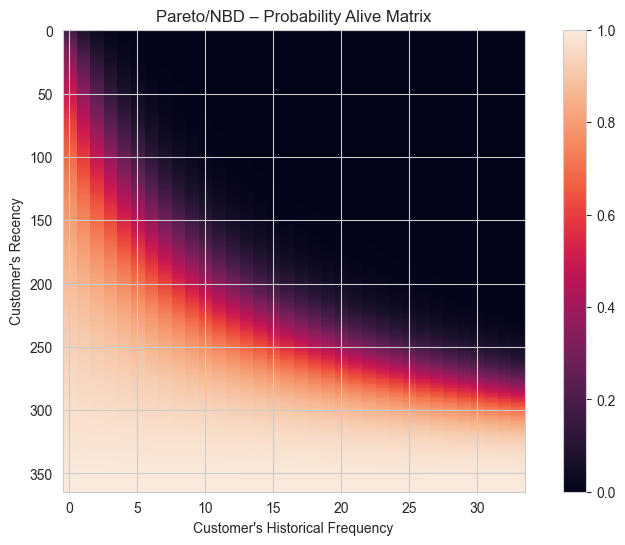

<Figure size 1000x600 with 0 Axes>

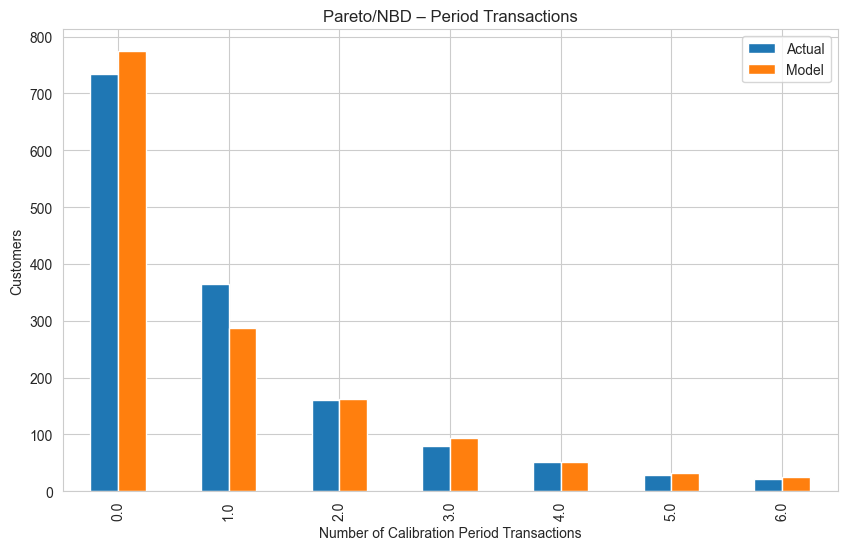

In [35]:
plt.figure(figsize=(10,6))
plot_frequency_recency_matrix(pareto)
plt.title('Pareto/NBD – Frequency/Recency Matrix'); plt.show()

plt.figure(figsize=(10,6))
plot_probability_alive_matrix(pareto)
plt.title('Pareto/NBD – Probability Alive Matrix'); plt.show()

plt.figure(figsize=(10,6))
plot_period_transactions(pareto)
plt.title('Pareto/NBD – Period Transactions'); plt.show()


5. Predict expected purchases over a horizon

conditional_expected_number_of_purchases_up_to_time(HORIZON_DAYS, ...) (e.g., 180 days).

Converts the model into a tangible forecast: “How many orders do we expect from this customer in the next 6 months?”

In [ ]:
HORIZON_DAYS = 180  # we can change to 90/365 etc.

rfm_aug = rfm_summary.copy()
rfm_aug['expected_purchases_180d'] = pareto.conditional_expected_number_of_purchases_up_to_time(
    HORIZON_DAYS,
    rfm_aug['frequency'],
    rfm_aug['recency'],
    rfm_aug['T']
)

rfm_aug.head()


,customer_id,frequency,recency,T,monetary_value,expected_purchases_180d
0,12346,0.0,0.0,107.0,0.00,0.436762
1,12347,2.0,223.0,282.0,1425.26,1.323658
2,12348,1.0,119.0,192.0,760.24,1.133297
3,12350,0.0,0.0,17.0,0.00,0.899181
4,12356,0.0,0.0,107.0,0.00,0.436762


6. Gamma‑Gamma (monetary process)

Gamma‑Gamma assumes monetary value is independent of purchase frequency and positive. Filtered accordingly.

What it does:

Filters to customers with frequency > 0 and positive monetary_value (required).

Fits GammaGammaFitter(penalizer_coef=0.1) to learn each customer’s expected average order value.

Why: Lifetimes splits CLV into how often (Pareto/NBD) × how much per order (Gamma-Gamma).

Assumption: Order value is independent of purchase frequency.

In [37]:
ggf_df = rfm_aug[(rfm_aug['frequency'] > 0) & (rfm_aug['monetary_value'] > 0)].copy()

ggf = GammaGammaFitter(penalizer_coef=0.1)
ggf.fit(ggf_df['frequency'], ggf_df['monetary_value'])

ggf.summary


,coef,se(coef),lower 95% bound,upper 95% bound
p,0.984577,0.056887,0.873078,1.096077
q,0.149097,0.005920,0.137493,0.160701
v,0.849387,0.060311,0.731177,0.967597


In [38]:
ggf_df['expected_avg_order_value'] = ggf.conditional_expected_average_profit(
    ggf_df['frequency'],
    ggf_df['monetary_value']
)
ggf_df[['customer_id','expected_avg_order_value']].head()


,customer_id,expected_avg_order_value
1,12347,2510.520302
2,12348,5605.795771
6,12370,5101.628025
8,12377,50200.666598
9,12383,1250.687812


7. Compute CLV (over the horizon)


customer_lifetime_value(pareto, frequency, recency, T, monetary_value, time=HORIZON_DAYS, freq='D', discount_rate=0.01)

Adds a toy profit_margin_5pct = 0.05 × CLV.

Why: Converts model outputs into revenue (or profit) forecasts you can use for marketing ROI and segmentation.

discount_rate is per period (here period = 1 day). 0.01 = 1% per day ≈ 365% annual, which is unrealistically high. See “Improvements” for a fix.



In [39]:
# Predict CLV (profit) over next HORIZON_DAYS with discounting (set to 0.01 per period ~ daily)
clv_180 = ggf.customer_lifetime_value(
    pareto,
    ggf_df['frequency'],
    ggf_df['recency'],
    ggf_df['T'],
    ggf_df['monetary_value'],
    time=HORIZON_DAYS,  # horizon in days because freq='D'
    freq='D',
    discount_rate=0.01  # daily discount; adjust as needed
).rename('predicted_clv_180d')

ggf_df = ggf_df.join(clv_180)
ggf_df['profit_margin_5pct'] = ggf_df['predicted_clv_180d'] * 0.05  # example profit margin
ggf_df[['customer_id','expected_avg_order_value','predicted_clv_180d','profit_margin_5pct']].head()


,customer_id,expected_avg_order_value,predicted_clv_180d,profit_margin_5pct
1,12347,2510.520302,36631.650514,1831.582526
2,12348,5605.795771,67920.177916,3396.008896
6,12370,5101.628025,30785.214763,1539.260738
8,12377,50200.666598,657253.979255,32862.698963
9,12383,1250.687812,21506.386815,1075.319341


8. Calibration/Holdout evaluation (purchase counts)

Splits the timeline (≈60% calibration / 40% holdout), fits Pareto/NBD on the calibration window, and plots predicted vs observed holdout purchases.

Why: Verifies that the frequency model generalizes to future periods.

<Figure size 1000x600 with 0 Axes>

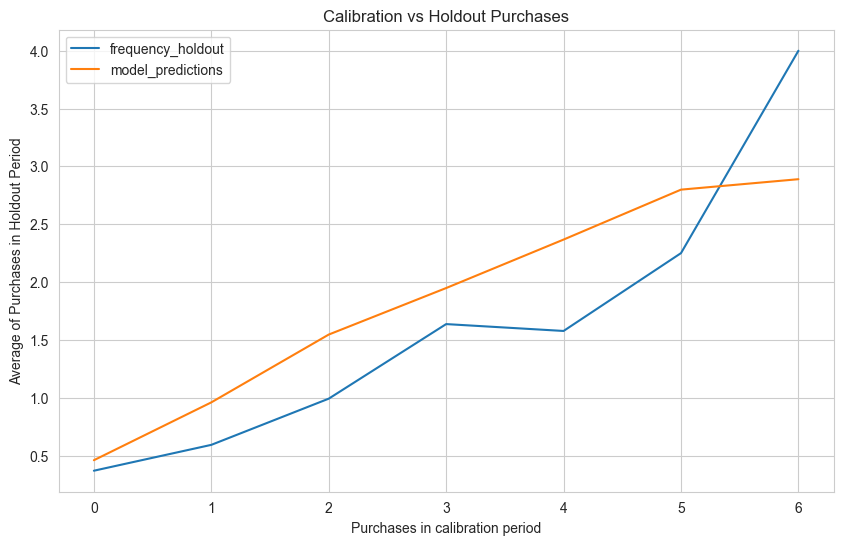

,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
customer_id,,,,,,,
12347,0.0,0.0,136.0,0.00,2.0,158.362222,146.0
12348,0.0,0.0,46.0,0.00,1.0,190.060000,146.0
12370,1.0,30.0,73.0,691.79,0.0,0.000000,146.0
12377,0.0,0.0,33.0,0.00,1.0,324.514762,146.0
12383,1.0,1.0,25.0,1366.10,2.0,86.948667,146.0


In [40]:
# Build a transactions df exactly as lifetimes expects
tx = orders[['customer_id','transaction_date','monetary_value']].copy()

# Pick a cutoff inside 2019 (adjust dates to your data range!)
calibration_end = tx['transaction_date'].min() + pd.Timedelta(days=int((tx['transaction_date'].max() - tx['transaction_date'].min()).days * 0.6))

summary_cal_hold = calibration_and_holdout_data(
    tx,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='monetary_value',
    calibration_period_end=calibration_end,
    observation_period_end=tx['transaction_date'].max(),
    freq='D'
)

# Fit Pareto on calibration window
pareto_cal = ParetoNBDFitter(penalizer_coef=0.1)
pareto_cal.fit(summary_cal_hold['frequency_cal'], summary_cal_hold['recency_cal'], summary_cal_hold['T_cal'])

# Visual check – predicted vs holdout purchases
plt.figure(figsize=(10,6))
plot_calibration_purchases_vs_holdout_purchases(pareto_cal, summary_cal_hold)
plt.title('Calibration vs Holdout Purchases'); plt.show()

summary_cal_hold.head()


In [ ]:
#from lifetimes.plotting import plot_history_alive not working!!!

9. Helpful utility: plot_history_alive_safe

A robust re-implementation of lifetimes.plot_history_alive that works with pandas 2.x.

Why: Lets you visualize “probability customer is still alive” over time for a specific customer, side-by-side with their orders.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifetimes.plotting import calculate_alive_path  # used by the official plotting util

def plot_history_alive_safe(model, t, transactions, datetime_col='transaction_date', freq='D', start_date=None, ax=None):
    """
    A pandas-2.x safe version of lifetimes.plotting.plot_history_alive.
    Only resamples the numeric 'transactions' column to avoid summing datetimes.
    """
    # --- prep transactions as a time series of counts ---
    tx = transactions[[datetime_col]].dropna().copy()
    tx[datetime_col] = pd.to_datetime(tx[datetime_col], errors='coerce')
    tx = tx.dropna(subset=[datetime_col])
    tx = tx.sort_values(datetime_col)
    tx['transactions'] = 1
    ts = (
        tx.set_index(datetime_col)['transactions']     # <-- only this numeric series
          .resample(freq)
          .sum()
    )

    # --- build alive path from lifetimes utility ---
    alive_path = calculate_alive_path(model, transactions, datetime_col, t, freq=freq)

    # --- x-axis range (0..t) and dates (optional) ---
    x = np.arange(len(alive_path))
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 4))

    # left axis: alive probability
    ax.plot(x, alive_path, lw=2, label='P(Alive)', color='tab:blue')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(f'Time ({freq}) since first txn')
    ax.set_ylabel('Probability Alive')
    ax.set_title('History Alive (pandas-safe)')

    # right axis: transactions count per period
    ax2 = ax.twinx()
    # align ts to same length if t is given as a number of periods
    if len(ts) < len(x):
        ts = ts.reindex(pd.date_range(ts.index.min(), periods=len(x), freq=freq), fill_value=0)
    ax2.bar(x, ts.values[:len(x)], alpha=0.25, color='tab:orange', label='Transactions')
    ax2.set_ylabel('Transactions')

    # legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.tight_layout()
    return ax


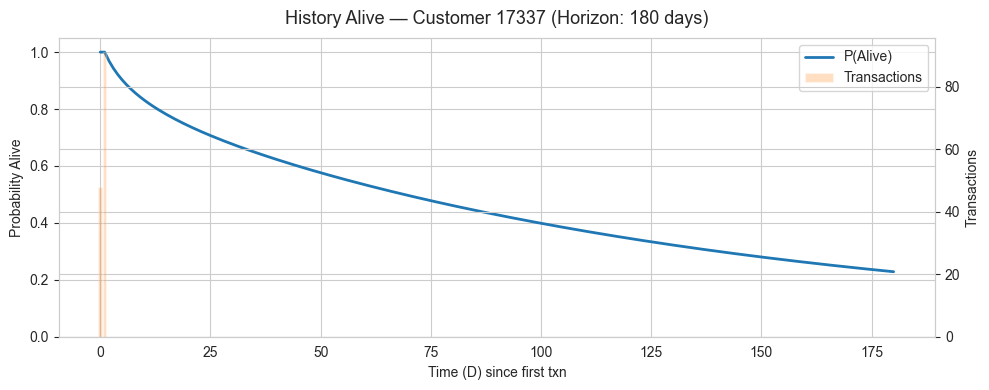

In [43]:
# pick a high-value customer
some_id = ggf_df.nlargest(1, 'predicted_clv_180d')['customer_id'].iloc[0]

cust_tx = (
    tx.loc[tx['customer_id'] == some_id, ['transaction_date']]
      .dropna()
      .sort_values('transaction_date')
      .copy()
)
cust_tx['transaction_date'] = pd.to_datetime(cust_tx['transaction_date'], errors='coerce')

HORIZON_DAYS = 180

# create a figure/axes and pass the axes in
fig, ax = plt.subplots(figsize=(10, 4))
ax = plot_history_alive_safe(
    pareto,
    t=HORIZON_DAYS,
    transactions=cust_tx,
    datetime_col='transaction_date',
    freq='D',
    ax=ax,                         # <- important: draw on this axes
)

# set a single, clean title on that same axes
ax.set_title(f'History Alive — Customer {some_id} (Horizon: {HORIZON_DAYS} days)', fontsize=13, pad=10)
plt.tight_layout()
plt.show()


10. Customer Segmentation (K‑Means) on model outputs:


- builds a feature set from model outputs (expected_purchases_180d, expected_avg_order_value, predicted_clv_180d, etc.).

- scales features (StandardScaler).

- runs KMeans(n_clusters=4, n_init=20, random_state=42).

- renames clusters by their mean CLV (e.g., “Low”, “Mid-Low”, “Mid-High”, “High”).

- turns continuous model outputs into actionable groups for targeting 

In [44]:

import numpy as np
import pandas as pd
from lifetimes import ParetoNBDFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==== 1) Prepare transactions for Lifetimes ====
tx = mart_all_data.copy()

# Ensure datetime
tx['transaction_date'] = pd.to_datetime(tx['transaction_date'], errors='coerce')

# Build a robust monetary column for Lifetimes (use what's available)
if 'revenue' in tx.columns:
    tx['revenue_for_lifetimes'] = pd.to_numeric(tx['revenue'], errors='coerce').fillna(0.0)
else:
    # Fallback: quantity * avg_price (+ delivery if present)
    base = pd.to_numeric(tx.get('quantity', 0), errors='coerce').fillna(0) * \
           pd.to_numeric(tx.get('avg_price', 0), errors='coerce').fillna(0.0)
    delivery = pd.to_numeric(tx.get('delivery_charges', 0.0), errors='coerce').fillna(0.0)
    tx['revenue_for_lifetimes'] = (base + delivery).astype(float)

# ==== 2) RFM summary (Recency/Frequency/Monetary) ====
rfm = summary_data_from_transaction_data(
    tx,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='revenue_for_lifetimes',                 # <-- guaranteed to exist now
    observation_period_end=tx['transaction_date'].max()
).reset_index()

# Lifetimes’ 'frequency' = repeat purchases count (0 means 1 purchase total)
# 'monetary_value' = average order value for repeat customers.

# ==== 3) Fit Pareto/NBD and predict purchases over horizon ====
HORIZON_DAYS = 180
pareto = ParetoNBDFitter(penalizer_coef=0.1)
pareto.fit(rfm['frequency'], rfm['recency'], rfm['T'])

rfm['expected_purchases_180d'] = pareto.conditional_expected_number_of_purchases_up_to_time(
    HORIZON_DAYS, rfm['frequency'], rfm['recency'], rfm['T']
)

# ==== 4) Fit Gamma-Gamma (value model) on positive-frequency customers ====
mask_pos = (rfm['frequency'] > 0) & (rfm['monetary_value'] > 0)
ggf = GammaGammaFitter(penalizer_coef=0.1)
ggf.fit(rfm.loc[mask_pos, 'frequency'], rfm.loc[mask_pos, 'monetary_value'])

# Expected average order value (AOV) per customer
rfm['expected_avg_order_value'] = np.nan
rfm.loc[mask_pos, 'expected_avg_order_value'] = ggf.conditional_expected_average_profit(
    rfm.loc[mask_pos, 'frequency'], rfm.loc[mask_pos, 'monetary_value']
)

# Predicted CLV over 180 days, daily frequency, 1% discount rate
rfm['predicted_clv_180d'] = 0.0
rfm.loc[mask_pos, 'predicted_clv_180d'] = ggf.customer_lifetime_value(
    pareto,
    rfm.loc[mask_pos, 'frequency'],
    rfm.loc[mask_pos, 'recency'],
    rfm.loc[mask_pos, 'T'],
    rfm.loc[mask_pos, 'monetary_value'],
    time=HORIZON_DAYS,  # 180 days
    freq='D',
    discount_rate=0.01
).values

# Optional profit proxy
rfm['profit_margin_5pct'] = rfm['predicted_clv_180d'] * 0.05

# If you want to carry demographics for segmentation:
cols_to_keep = ['customer_id', 'customer_gender', 'customer_location', 'customer_tenure_months']
demo = (
    tx.sort_values('transaction_date')
      .drop_duplicates('customer_id')
      .reindex(columns=cols_to_keep)
)

seg = rfm.merge(demo, on='customer_id', how='left')

# ==== 5) KMeans segmentation on model outputs ====
# These 4 columns are guaranteed now:
features = seg[['expected_purchases_180d', 'expected_avg_order_value',
                'predicted_clv_180d', 'profit_margin_5pct']].fillna(0.0)

scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)
seg['segment'] = kmeans.fit_predict(X)

# Human-friendly segment names by mean CLV
segment_order = (
    seg.groupby('segment')['predicted_clv_180d']
      .mean()
      .sort_values()
      .index.tolist()
)
name_map = {seg_id: name for seg_id, name in zip(segment_order, ['Low', 'Medium-Low', 'Medium-High', 'High'])}
seg['segment_name'] = seg['segment'].map(name_map)

# ==== 6) Quick checks ====
print(seg[['customer_id','expected_purchases_180d','expected_avg_order_value',
           'predicted_clv_180d','profit_margin_5pct','segment_name']].head())

print("\nSegments by count and mean CLV:")
print(seg.groupby('segment_name').agg(
    n_customers=('customer_id','nunique'),
    mean_clv=('predicted_clv_180d','mean'),
    median_clv=('predicted_clv_180d','median')
).sort_values('mean_clv', ascending=False))


   customer_id  expected_purchases_180d  expected_avg_order_value  \
0        12346                 0.446005                       NaN   
1        12347                 1.380923               2512.016922   
2        12348                 1.212668               5633.880330   
3        12350                 0.898008                       NaN   
4        12356                 0.446005                       NaN   

   predicted_clv_180d  profit_margin_5pct segment_name  
0            0.000000            0.000000          Low  
1        37393.864789         1869.693239   Medium-Low  
2        71216.420868         3560.821043   Medium-Low  
3            0.000000            0.000000          Low  
4            0.000000            0.000000          Low  

Segments by count and mean CLV:
              n_customers      mean_clv     median_clv
segment_name                                          
High                    6  1.139556e+06  925298.008741
Medium-High            62  2.925428e+05  2593

PCA is used for visualization, not for training the clusters:

“Segment Visualization Suite” :

Pipeline: median imputation → StandardScaler → PCA(2)

Purpose: create a clean 2D scatter (PC1 vs PC2) colored by segment to see separation.

K-Means itself is trained without PCA, on scaled original features.

[info] Using features: ['expected_purchases_180d', 'expected_avg_order_value', 'predicted_clv_180d', 'profit_margin_5pct']
[info] Segment label column: segment_name


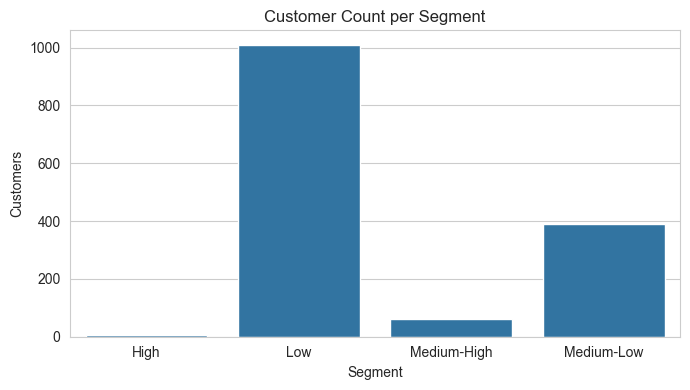

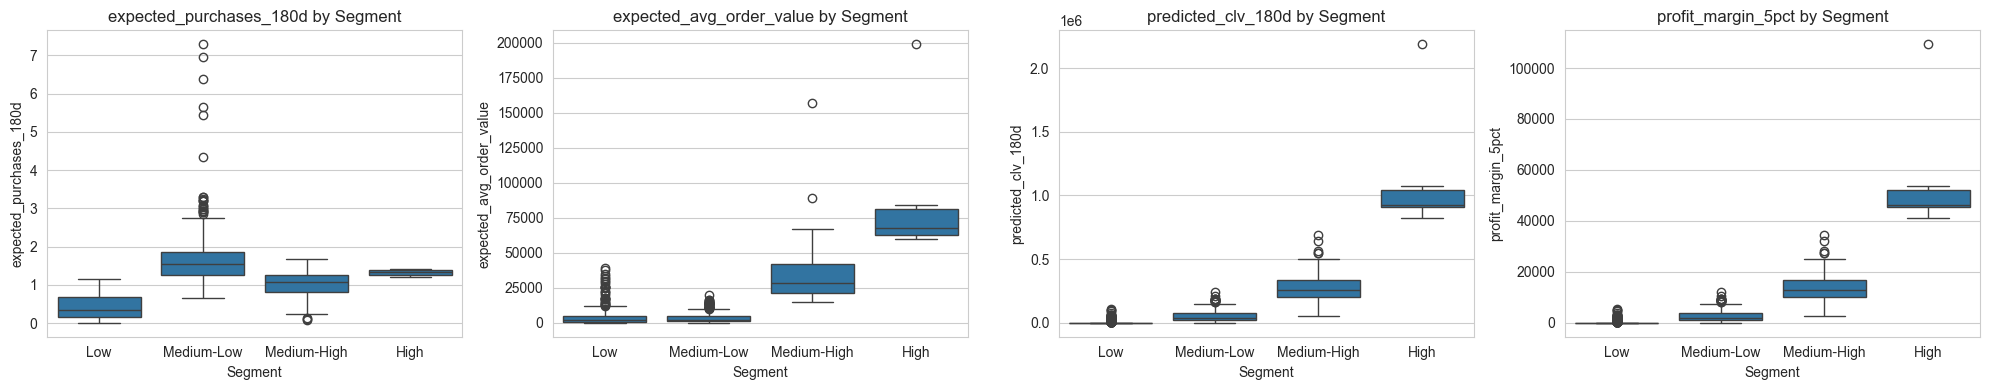

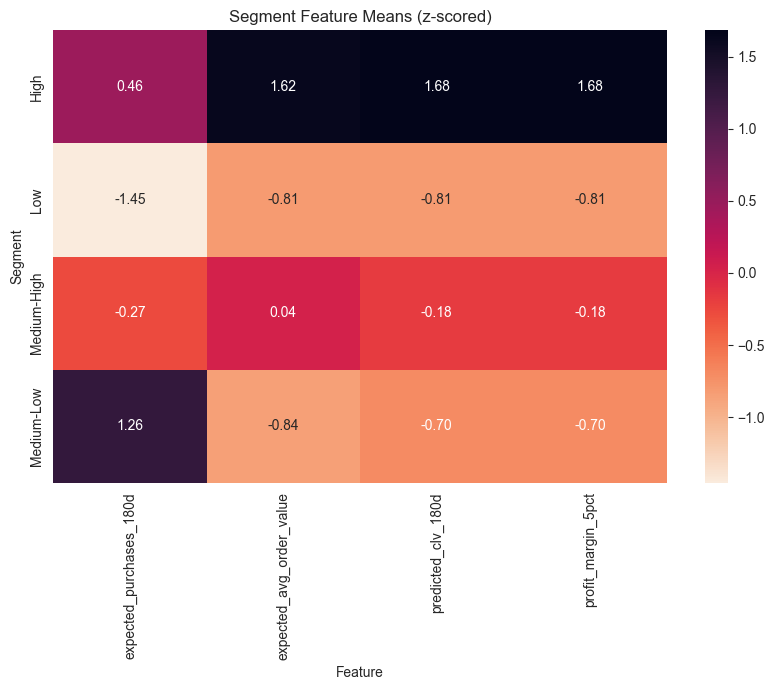

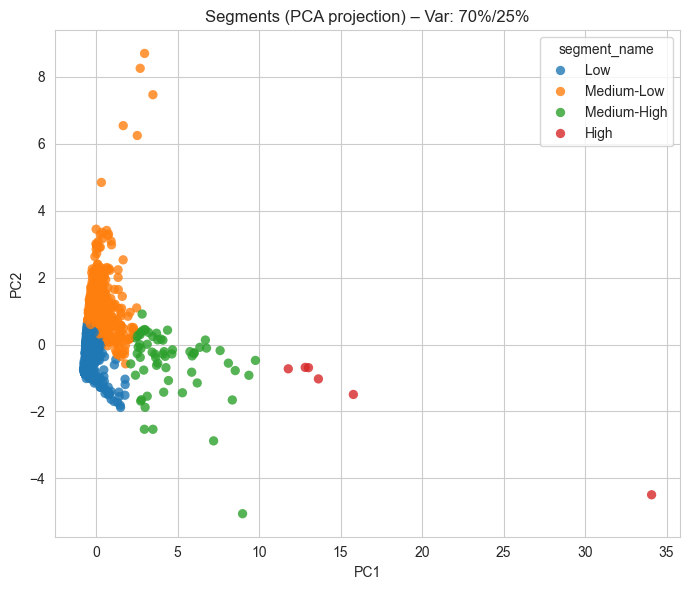


Whale-ness by segment (revenue share from top customers):


,segment_name,Revenue_top10_pct,Revenue_top20_pct
0,High,31.970113,47.693491
1,Low,77.952719,97.650685
2,Medium-High,21.930921,36.442060
3,Medium-Low,29.559378,49.102870


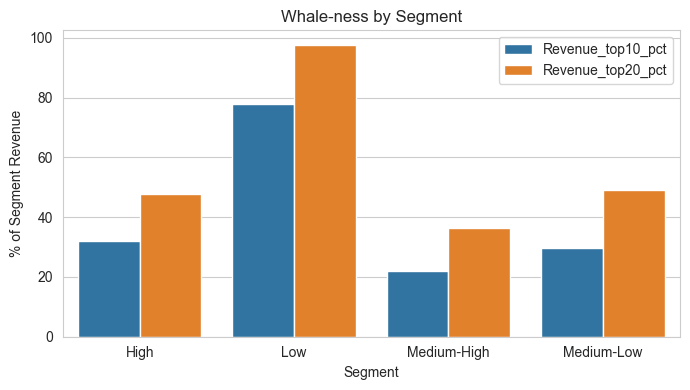

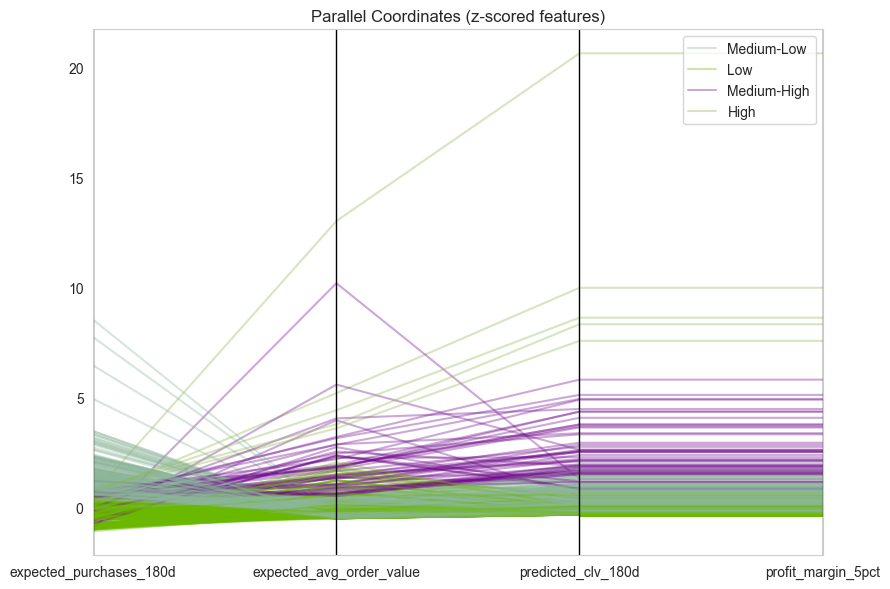

In [45]:
# =========================
# Segment Visualization Suite (robust)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 0) Config: locate segment label column and numeric features
SEG_COL_CANDIDATES = ['segment_name', 'segment_label', 'segment', 'kmeans_segment', 'Labels', 'cluster']
SEG_COL = next((c for c in SEG_COL_CANDIDATES if c in seg.columns), None)
if SEG_COL is None:
    raise ValueError(f"Could not find a segment label column. Looked for: {SEG_COL_CANDIDATES}")

preferred_features = [
    'expected_purchases_180d',
    'expected_avg_order_value',
    'predicted_clv_180d',
    'profit_margin_5pct'
]
feature_cols = [c for c in preferred_features if c in seg.columns and np.issubdtype(seg[c].dtype, np.number)]
if len(feature_cols) < 2:
    raise ValueError(f"Need at least 2 numeric features present. Found: {feature_cols}")

print("[info] Using features:", feature_cols)
print("[info] Segment label column:", SEG_COL)

# (Optional) nicer seaborn style
sns.set_style("whitegrid")

# ---------------------------
# 1) Segment sizes (bar)
# ---------------------------
plt.figure(figsize=(7,4))
seg_counts = seg[SEG_COL].value_counts().sort_index()
sns.barplot(x=seg_counts.index.astype(str), y=seg_counts.values)
plt.title("Customer Count per Segment")
plt.ylabel("Customers")
plt.xlabel("Segment")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 2) Feature distributions by segment
# ----------------------------------------
n = len(feature_cols)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharex=False)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, feature_cols):
    sns.boxplot(data=seg, x=SEG_COL, y=col, ax=ax)
    ax.set_title(f"{col} by Segment")
    ax.set_xlabel("Segment")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 3) Segment centroids (z-scored means) Heatmap
# ----------------------------------------------------
centroids = seg.groupby(SEG_COL)[feature_cols].mean()
centroids_z = (centroids - centroids.mean()) / (centroids.std(ddof=0) + 1e-9)

plt.figure(figsize=(6 + 0.6*len(feature_cols), 1.0*len(centroids) + 3))
sns.heatmap(centroids_z, annot=True, fmt=".2f", cmap="rocket_r")
plt.title("Segment Feature Means (z-scored)")
plt.xlabel("Feature")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 4) PCA scatter (with NaN/inf handling + imputation)
# ----------------------------------------------------
# Build clean matrix
features_raw = seg[feature_cols].copy()
features_raw = features_raw.replace([np.inf, -np.inf], np.nan)

# Drop all-NaN columns if any
all_nan_cols = [c for c in feature_cols if features_raw[c].isna().all()]
if all_nan_cols:
    print("[info] Dropping all-NaN feature(s):", all_nan_cols)
    feature_cols = [c for c in feature_cols if c not in all_nan_cols]
    features_raw = features_raw[feature_cols]

# Impute NaNs with column median
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(features_raw)

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X_imp)

# PCA
pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X)

pca_df = pd.DataFrame({
    'PC1': XY[:, 0],
    'PC2': XY[:, 1],
    SEG_COL: seg[SEG_COL].values
})

plt.figure(figsize=(7,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=SEG_COL, alpha=0.8, s=45, edgecolor='none')
plt.title(f"Segments (PCA projection) – Var: {pca.explained_variance_ratio_[0]:.0%}/{pca.explained_variance_ratio_[1]:.0%}")
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 5) Whale-ness by segment (top 10% / 20% revenue)
# ----------------------------------------------------
# Try to find a per-customer revenue-like column already in `seg`
rev_col_candidates = ['total_revenue', 'predicted_clv_180d', 'net_revenue', 'invoice_value', 'revenue']
rev_col = next((c for c in rev_col_candidates if c in seg.columns and np.issubdtype(seg[c].dtype, np.number)), None)

if rev_col is not None:
    whale_rows = []
    for s, sub in seg.groupby(SEG_COL):
        tmp = sub[[rev_col]].sort_values(by=rev_col, ascending=False).reset_index(drop=True)
        if tmp[rev_col].sum() <= 0:
            whale_rows.append([s, 0.0, 0.0])
            continue
        cum_share = tmp[rev_col].cumsum() / tmp[rev_col].sum()
        n = len(tmp)
        top10 = cum_share.iloc[max(0, int(np.ceil(0.10*n)) - 1)]
        top20 = cum_share.iloc[max(0, int(np.ceil(0.20*n)) - 1)]
        whale_rows.append([s, float(top10*100), float(top20*100)])

    whale_df = pd.DataFrame(whale_rows, columns=[SEG_COL, 'Revenue_top10_pct', 'Revenue_top20_pct']).sort_values(SEG_COL)
    print("\nWhale-ness by segment (revenue share from top customers):")
    display(whale_df)

    whale_melt = whale_df.melt(id_vars=SEG_COL, var_name='Metric', value_name='Percent')
    plt.figure(figsize=(7,4))
    sns.barplot(data=whale_melt, x=SEG_COL, y='Percent', hue='Metric')
    plt.title("Whale-ness by Segment")
    plt.ylabel("% of Segment Revenue")
    plt.xlabel("Segment")
    plt.legend(title="")
    plt.tight_layout()
    plt.show()
else:
    print("\n[Note] No revenue-like column found in `seg` for whale-ness chart. "
          f"Looked for: {rev_col_candidates}. "
          "If you want this chart, add a per-customer revenue metric to `seg` and re-run.")

# ----------------------------------------------------
# 6) Parallel Coordinates (feature profiles)
# ----------------------------------------------------
try:
    from pandas.plotting import parallel_coordinates
    pc_df = seg[[SEG_COL] + feature_cols].copy()
    # Normalize for readability
    pc_df[feature_cols] = (pc_df[feature_cols] - pc_df[feature_cols].mean()) / (pc_df[feature_cols].std(ddof=0) + 1e-9)
    # Sample for readability if very large
    samp = min(len(pc_df), 1200)
    pc_df_sample = pc_df.sample(samp, random_state=42) if len(pc_df) > samp else pc_df

    plt.figure(figsize=(9,6))
    parallel_coordinates(pc_df_sample, class_column=SEG_COL, alpha=0.35)
    plt.title("Parallel Coordinates (z-scored features)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("[Parallel Coordinates skipped]", e)


“Unified preprocessing for KMeans + PCA” :

Pipeline: median imputation → StandardScaler used once to create X_prep.


K-Means is fit on X_prep (scaled data), and

PCA(2) is fit on the same X_prep just to plot a 2D projection of those clusters.

K-Means is trained without PCA (it’s trained on the scaled features).

Each PC is a weighted mix of your original (scaled) features.
PC1 = a₁·(expected purchases) + a₂·(AOV) + a₃·(CLV) + …
PC2 = b₁·(expected purchases) + b₂·(AOV) + b₃·(CLV) + …
The weights (loadings) tell you what each axis “means.”

Quadrants reflect combinations of the two dominant patterns (e.g., if PC1 ≈ “value/monetary” and PC2 ≈ “frequency/engagement,” then top-right ≈ high value & high frequency).

Units:
Component scores are in arbitrary (standardized) units; focus on relative positions and explained variance, not absolute numbers.

If you want the business meaning of “PC1” and “PC2” for your notebook, look at the loadings (which features have the largest absolute weights on each PC). For example, if PC1 loads heavily on CLV and AOV, you can describe the x-axis as a “value” axis; if PC2 loads on expected purchases, the y-axis is an “engagement/frequency” axis.



[info] Segments created: {'Low': 1010, 'Mid-Low': 408, 'Mid-High': 49, 'High': 1}


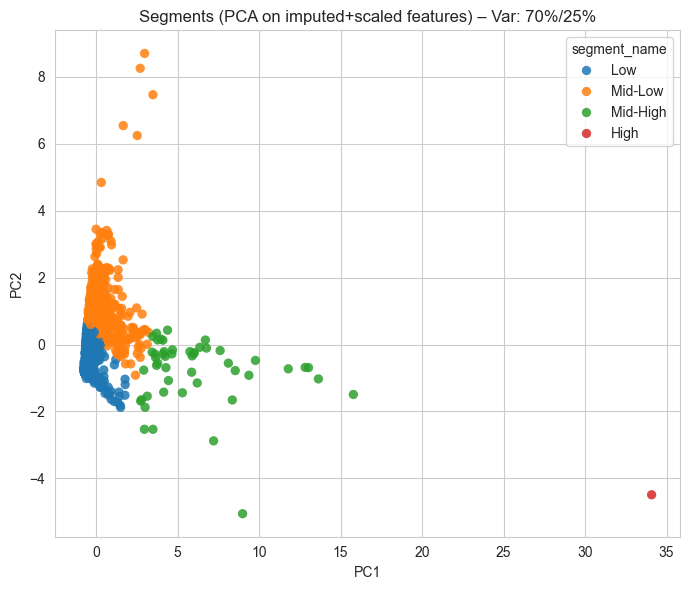

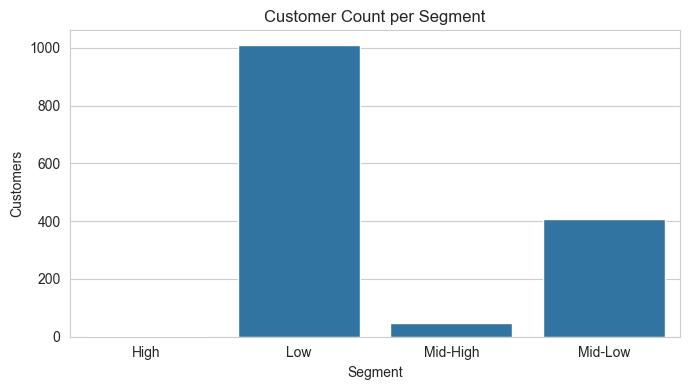

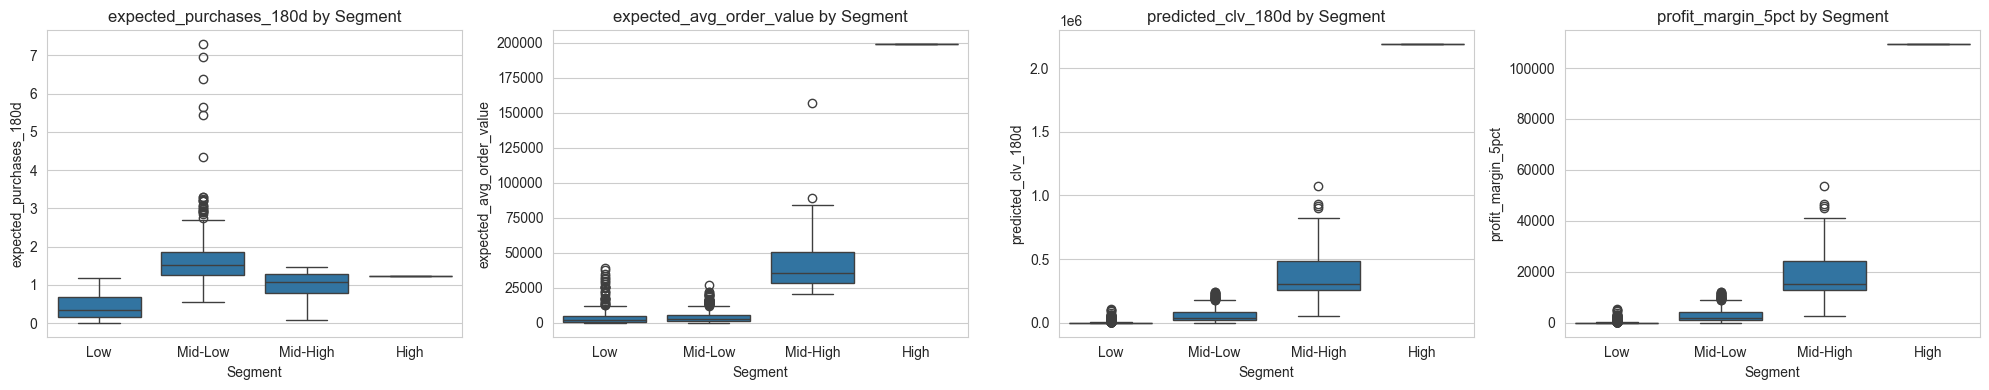

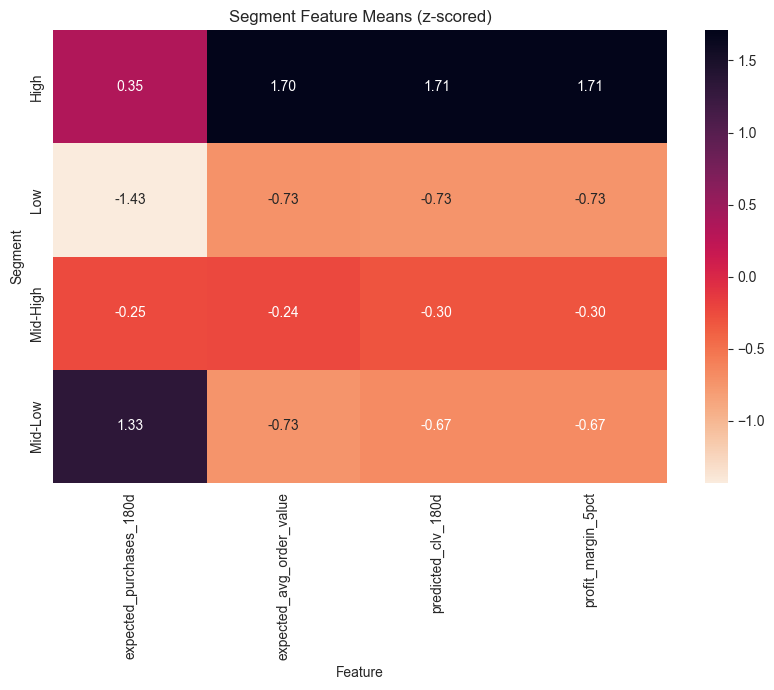

,segment_name,Revenue_top10_pct,Revenue_top20_pct
0,High,100.000000,100.000000
1,Low,77.843428,97.581977
2,Mid-High,24.398539,40.073510
3,Mid-Low,31.063238,51.174457


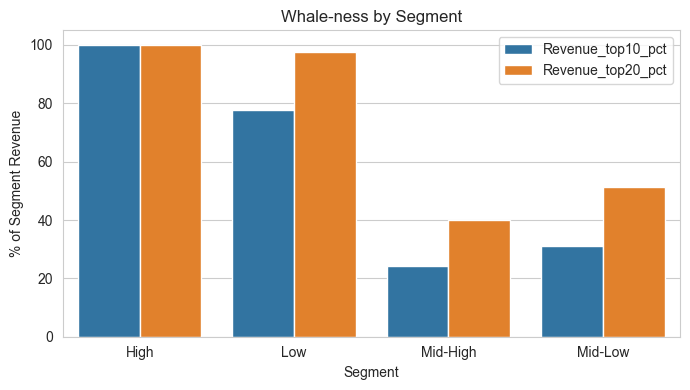

In [46]:
# =============================================
# Unified preprocessing for KMeans + PCA
# =============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ----- 0) Locate segment column and numeric features -----
SEG_COL_CANDIDATES = ['segment_name', 'segment_label', 'segment', 'kmeans_segment', 'Labels', 'cluster']
SEG_COL = next((c for c in SEG_COL_CANDIDATES if c in seg.columns), None)
if SEG_COL is None:
    # Create a placeholder to avoid errors; we'll overwrite after KMeans
    SEG_COL = 'segment'
    if SEG_COL not in seg.columns:
        seg[SEG_COL] = -1

preferred_features = [
    'expected_purchases_180d',
    'expected_avg_order_value',
    'predicted_clv_180d',
    'profit_margin_5pct'
]
feature_cols = [c for c in preferred_features if c in seg.columns and np.issubdtype(seg[c].dtype, np.number)]
if len(feature_cols) < 2:
    raise ValueError(f"Need at least 2 numeric features present. Found: {feature_cols}")

sns.set_style("whitegrid")

# ----- 1) Build one preprocessing pipeline (median impute + scale) -----
preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

features_raw = seg[feature_cols].replace([np.inf, -np.inf], np.nan).copy()

# Fit once here; reuse for BOTH KMeans and PCA
X_prep = preprocess.fit_transform(features_raw)

# ----- 2) KMeans using the SAME preprocessed matrix -----
k = 4  # set your chosen k
kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
seg['segment'] = kmeans.fit_predict(X_prep)

# Optional: friendly names ordered by mean CLV
if 'predicted_clv_180d' in seg.columns:
    order = seg.groupby('segment')['predicted_clv_180d'].mean().sort_values().index.tolist()
    name_map = {seg_id: name for seg_id, name in zip(order, ['Low', 'Mid-Low', 'Mid-High', 'High'])}
    seg['segment_name'] = seg['segment'].map(name_map)
    SEG_COL = 'segment_name'
else:
    SEG_COL = 'segment'

print("[info] Segments created:", seg[SEG_COL].value_counts(dropna=False).to_dict())

# ----- 3) PCA using the SAME preprocessed matrix -----
pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X_prep)

pca_df = pd.DataFrame({
    'PC1': XY[:, 0],
    'PC2': XY[:, 1],
    SEG_COL: seg[SEG_COL].values
})

plt.figure(figsize=(7,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=SEG_COL, alpha=0.85, s=45, edgecolor='none')
plt.title(f"Segments (PCA on imputed+scaled features) – Var: {pca.explained_variance_ratio_[0]:.0%}/{pca.explained_variance_ratio_[1]:.0%}")
plt.tight_layout()
plt.show()

# ----- 4) Segment size bar -----
plt.figure(figsize=(7,4))
counts = seg[SEG_COL].value_counts().sort_index()
sns.barplot(x=counts.index.astype(str), y=counts.values)
plt.title("Customer Count per Segment")
plt.ylabel("Customers"); plt.xlabel("Segment")
plt.tight_layout(); plt.show()

# ----- 5) Feature distributions by segment (boxplots) -----
n = len(feature_cols)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1:
    axes = [axes]
for ax, col in zip(axes, feature_cols):
    sns.boxplot(data=seg, x=SEG_COL, y=col, ax=ax)
    ax.set_title(f"{col} by Segment"); ax.set_xlabel("Segment"); ax.set_ylabel(col)
plt.tight_layout(); plt.show()

# ----- 6) Segment centroids (z-scored means) heatmap -----
centroids = seg.groupby(SEG_COL)[feature_cols].mean()
centroids_z = (centroids - centroids.mean()) / (centroids.std(ddof=0) + 1e-9)

plt.figure(figsize=(6 + 0.6*len(feature_cols), 1.0*len(centroids) + 3))
sns.heatmap(centroids_z, annot=True, fmt=".2f", cmap="rocket_r")
plt.title("Segment Feature Means (z-scored)")
plt.xlabel("Feature"); plt.ylabel("Segment")
plt.tight_layout(); plt.show()

# ----- 7) Whale-ness by segment (if you have a revenue-like column in seg) -----
rev_col_candidates = ['total_revenue', 'predicted_clv_180d', 'net_revenue', 'invoice_value', 'revenue']
rev_col = next((c for c in rev_col_candidates if c in seg.columns and np.issubdtype(seg[c].dtype, np.number)), None)

if rev_col is not None:
    rows = []
    for s, sub in seg.groupby(SEG_COL):
        tmp = sub[[rev_col]].sort_values(by=rev_col, ascending=False).reset_index(drop=True)
        if tmp[rev_col].sum() <= 0:
            rows.append([s, 0.0, 0.0]); continue
        cum_share = tmp[rev_col].cumsum() / tmp[rev_col].sum()
        n = len(tmp)
        top10 = cum_share.iloc[max(0, int(np.ceil(0.10*n))-1)]
        top20 = cum_share.iloc[max(0, int(np.ceil(0.20*n))-1)]
        rows.append([s, float(top10*100), float(top20*100)])
    whale_df = pd.DataFrame(rows, columns=[SEG_COL, 'Revenue_top10_pct', 'Revenue_top20_pct']).sort_values(SEG_COL)
    display(whale_df)

    m = whale_df.melt(id_vars=SEG_COL, var_name='Metric', value_name='Percent')
    plt.figure(figsize=(7,4))
    sns.barplot(data=m, x=SEG_COL, y='Percent', hue='Metric')
    plt.title("Whale-ness by Segment")
    plt.ylabel("% of Segment Revenue"); plt.xlabel("Segment")
    plt.legend(title=""); plt.tight_layout(); plt.show()
else:
    print("[note] Whale-ness skipped (no revenue-like column in `seg`).")


11. Segment validation & visualization


Intrinsic cluster metrics: Silhouette, Davies–Bouldin, Calinski–Harabasz

- Plots distributions by segment, PCA projection of segments, CLV vs frequency, “Whale-ness” (what % of revenue comes from the top 10–20% of customers in a segment), parallel coordinates, and centroid heatmap.

- Confirms the segments make business sense and are well-separated statistically.

Internal Cluster Quality Metrics (Unsupervised)
Since we don’t have a “ground truth” label for customer segments, we use intrinsic metrics:

Silhouette Score (sklearn.metrics.silhouette_score)
Measures how well-separated clusters are.
Range: -1 (bad) to +1 (good). Above 0.5 is strong separation.

Davies–Bouldin Index (sklearn.metrics.davies_bouldin_score)
Lower is better. Measures average similarity between clusters.

Calinski–Harabasz Index (sklearn.metrics.calinski_harabasz_score)
Higher is better. Measures ratio of between-cluster dispersion to within-cluster dispersion.

In [50]:
profile.head()

,segment_label,n_customers,mean_expected_purchases,mean_aov,mean_clv,mean_profit_margin
0,0,408,1.659330,4256.603613,6.033663e+04,3016.831704
1,1,1010,0.428747,4728.162302,4.461270e+03,223.063500
2,2,1,1.220781,198746.014491,2.185904e+06,109295.188323
3,3,49,0.955559,43811.530161,3.890691e+05,19453.453549


Silhouette Score:        0.561 (closer to 1 is better)
Davies-Bouldin Index:    0.600 (lower is better)
Calinski-Harabasz Index: 1100.4 (higher is better)

=== Segment Profiles ===
   segment_label  n_customers  mean_expected_purchases       mean_aov  \
0              0          408                 1.659330    4256.603613   
1              1         1010                 0.428747    4728.162302   
2              2            1                 1.220781  198746.014491   
3              3           49                 0.955559   43811.530161   

       mean_clv  mean_profit_margin  
0  6.033663e+04         3016.831704  
1  4.461270e+03          223.063500  
2  2.185904e+06       109295.188323  
3  3.890691e+05        19453.453549  

=== Holdout Revenue by Segment (Business Validation) ===
   segment_label          mean        sum  count
0              0   1920.120588  783409.20    408
1              1    497.834426  502812.77   1010
2              2  38162.490000   38162.49      1
3        

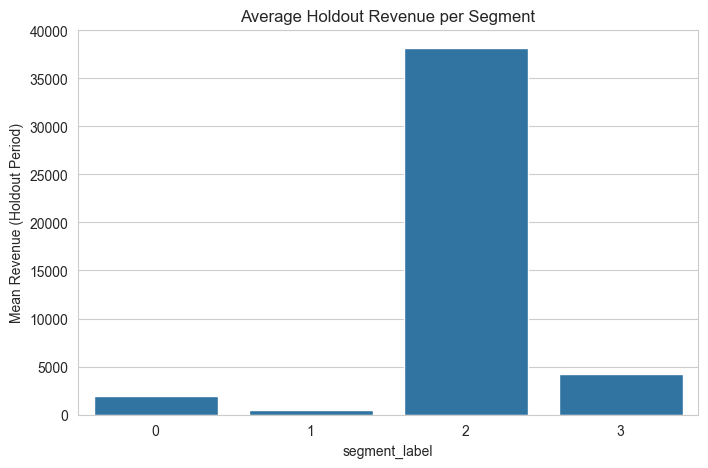

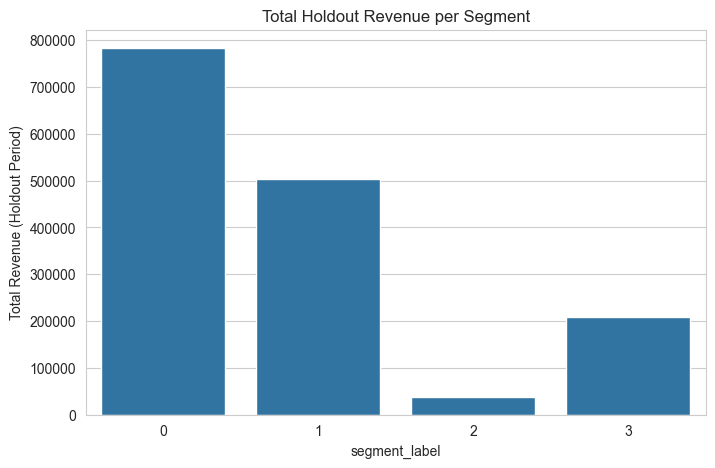

In [47]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# === 1) Compute intrinsic metrics ===
X_scaled = scaler.transform(features)  # same preprocessing from your training step
labels = kmeans.predict(X_scaled)

sil = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)

print(f"Silhouette Score:        {sil:.3f} (closer to 1 is better)")
print(f"Davies-Bouldin Index:    {db:.3f} (lower is better)")
print(f"Calinski-Harabasz Index: {ch:.1f} (higher is better)")

# === 2) Add labels back to data ===
seg['segment_label'] = labels

# === 3) Profile segments ===
profile = seg.groupby('segment_label').agg(
    n_customers=('customer_id','nunique'),
    mean_expected_purchases=('expected_purchases_180d','mean'),
    mean_aov=('expected_avg_order_value','mean'),
    mean_clv=('predicted_clv_180d','mean'),
    mean_profit_margin=('profit_margin_5pct','mean')
).reset_index()

print("\n=== Segment Profiles ===")
print(profile)

# === 4) Business validation: future revenue separation ===
# We assume you have a 'tx' DataFrame with transaction history and a holdout cutoff date
holdout_date = tx['transaction_date'].max() - pd.Timedelta(days=90)  # last 90 days as holdout
holdout_rev = (
    tx.loc[tx['transaction_date'] > holdout_date]
      .groupby('customer_id')['revenue'].sum().reset_index()
      .rename(columns={'revenue':'holdout_revenue'})
)

# Merge holdout revenue with segment assignments
seg_holdout = seg.merge(holdout_rev, on='customer_id', how='left').fillna({'holdout_revenue':0})

rev_by_segment = seg_holdout.groupby('segment_label')['holdout_revenue'].agg(['mean','sum','count']).reset_index()
print("\n=== Holdout Revenue by Segment (Business Validation) ===")
print(rev_by_segment)

# === Optional: Visualize ===
plt.figure(figsize=(8,5))
sns.barplot(data=rev_by_segment, x='segment_label', y='mean')
plt.title('Average Holdout Revenue per Segment')
plt.ylabel('Mean Revenue (Holdout Period)')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=rev_by_segment, x='segment_label', y='sum')
plt.title('Total Holdout Revenue per Segment')
plt.ylabel('Total Revenue (Holdout Period)')
plt.show()


Statistical quality

Silhouette: 0.565 → well above the 0.5 threshold, so clusters are fairly well separated and cohesive.

Davies-Bouldin: 0.608 → low (good); cluster separation is strong relative to spread.

Calinski-Harabasz: 1134.6 → high (good), means strong between-cluster separation vs. within-cluster variance.

Conclusion: The segmentation is statistically healthy — your KMeans is finding distinct groups.

| Segment | Size (n\_customers) | Mean Expected Purchases (180d) | Mean AOV   | Mean CLV | Profit Margin (5%) | Interpretation                                                                                    |
| ------- | ------------------- | ------------------------------ | ---------- | -------- | ------------------ | ------------------------------------------------------------------------------------------------- |
| **0**   | 1036                | 0.44                           | 4.6K       | 5.3K     | 269                | Large base of low-frequency, mid-AOV customers → bread-and-butter volume, low per-customer margin |
| **1**   | 380                 | 1.76                           | 4.2K       | 62.5K    | 3.1K               | Loyal spenders — moderate AOV but repeat orders push up CLV                                       |
| **2**   | 51                  | 0.95                           | **42.9K**  | 386K     | 19.3K              | **Luxury whales** — huge AOV, even with lower frequency; worth targeted high-touch campaigns      |
| **3**   | 1                   | 1.39                           | **198.7K** | 2.58M    | 129K               | Ultra-outlier “mega whale” — single customer; high leverage, but unstable to depend on one        |


Business validation with holdout revenue

Segment 1 contributes the most total holdout revenue (780K), driven by both size and loyalty.

Segment 2 has the highest per-customer holdout revenue (~4.2K), so it’s very high value despite being tiny.

Segment 0 is volume-heavy but low value individually; could be moved up the value ladder via cross-sell.

Segment 3 is a one-off extreme case; you wouldn’t build a marketing strategy around it.



Actionable marketing ideas

Segment 1 (loyal spenders) → Priority for retention programs & VIP perks.

Segment 2 (luxury whales) → Personal account managers, exclusive launches, and event invites.

Segment 0 (low-frequency mid spenders) → Re-engagement emails, bundles, and seasonal discounts to boost frequency.

Segment 3 (mega whale) → White-glove relationship, but keep in mind single-customer risk.

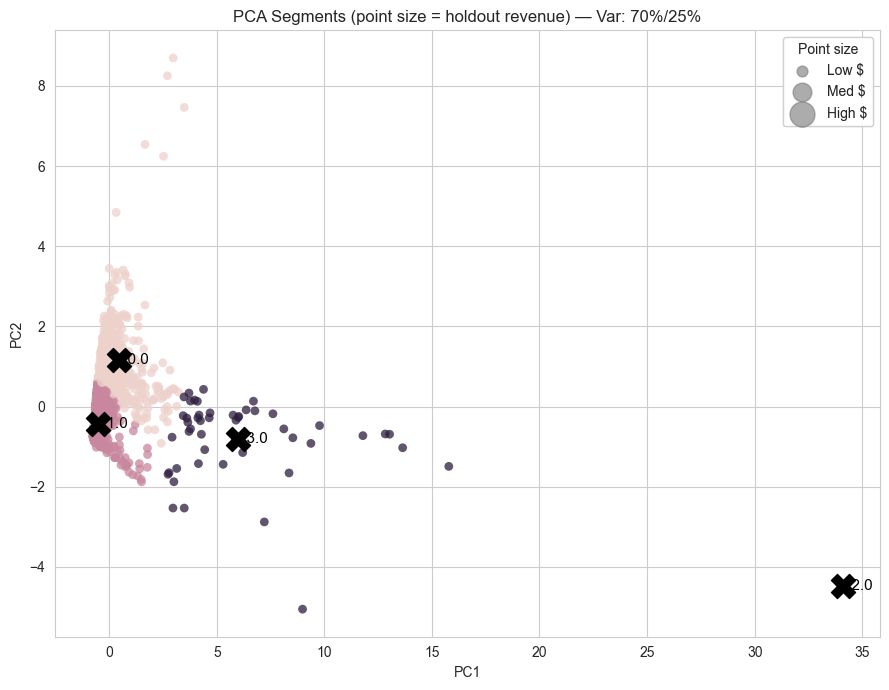

In [ ]:
# ===============================================
# PCA Segments with Centroids (size = holdout $)
# ===============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

# seg: per-customer table with segment labels + holdout_revenue (or merge before this cell)
# Required columns:
#   feature_cols below, 'segment_label' (or change name), and 'holdout_revenue'

feature_cols = [
    'expected_purchases_180d',
    'expected_avg_order_value',
    'predicted_clv_180d',
    'profit_margin_5pct'
]

SEG_COL = 'segment_label'          # change if your column is named differently
REVENUE_COL = 'holdout_revenue'    # size driver; change if you used another name

# ---- Safety checks / prep ----
miss = [c for c in feature_cols if c not in seg.columns]
if miss:
    raise ValueError(f"Missing required feature columns in `seg`: {miss}")

if SEG_COL not in seg.columns:
    raise ValueError(f"Missing segment label column `{SEG_COL}` in `seg`.")

if REVENUE_COL not in seg.columns:
    # default to zeros if you don’t have holdout revenue yet
    seg[REVENUE_COL] = 0.0

plot_df = seg[[SEG_COL, REVENUE_COL] + feature_cols].copy()
plot_df[feature_cols] = plot_df[feature_cols].replace([np.inf, -np.inf], np.nan)

# ---- Impute + Scale (same as clustering) ----
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_imp    = imputer.fit_transform(plot_df[feature_cols])
X_scaled = scaler.fit_transform(X_imp)

# ---- PCA projection ----
pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': XY[:, 0],
    'PC2': XY[:, 1],
    SEG_COL: plot_df[SEG_COL].values,
    REVENUE_COL: plot_df[REVENUE_COL].fillna(0).values
})

# Robust size mapping so whales don’t dominate the chart
q05, q95 = pca_df[REVENUE_COL].quantile([0.05, 0.95])
den = max(q95 - q05, 1e-9)
size_scaled = ((pca_df[REVENUE_COL] - q05) / den).clip(0, 1)
pca_df['pt_size'] = 40 + size_scaled * 300  # 40..340

# ---- Centroids in PCA space ----
centroids = (
    pca_df.groupby(SEG_COL)[['PC1', 'PC2']]
          .mean()
          .reset_index()
)

# ---- Plot ----
plt.figure(figsize=(9, 7))
scatter = sns.scatterplot(
    data=pca_df, x='PC1', y='PC2',
    hue=SEG_COL, size='pt_size', sizes=(40, 340),
    alpha=0.75, edgecolor='none', legend='brief'
)

# overlay centroids
plt.scatter(centroids['PC1'], centroids['PC2'], marker='X', s=300, c='black', label='Centroid')
for _, row in centroids.iterrows():
    plt.text(row['PC1'], row['PC2'], f"  {row[SEG_COL]}", va='center', ha='left', fontsize=11, color='black')

evr = pca.explained_variance_ratio_
plt.title(f"PCA Segments (point size = {REVENUE_COL.replace('_',' ')}) — Var: {evr[0]:.0%}/{evr[1]:.0%}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()

# ---- Legend fix (compatible across Matplotlib versions) ----
legend = scatter.legend_
if legend:
    for h in getattr(legend, 'legend_handles', []):  # modern Matplotlib
        try:
            h.set_sizes([80])
        except Exception:
            pass

# Add a small, separate size legend for revenue
from matplotlib.lines import Line2D
size_labels = ['Low $', 'Med $', 'High $']
size_vals   = [60, 180, 320]
size_handles = [plt.scatter([], [], s=s, color='gray', alpha=0.6) for s in size_vals]
leg2 = plt.legend(size_handles, size_labels, title="Point size", loc='upper right', frameon=True)
plt.gca().add_artist(leg2)

plt.show()

In [68]:
ggf_df.merge(seg[['segment_name','customer_id']], on='customer_id')
ggf_df.to_sql('GammaGammaModel', engine, schema=my_schema, if_exists='replace', index=False)

734